# 8. Shrinkage de la Matriz de Covarianza: Estimador de Ledoit-Wolf

## Motivación: el problema de la inestabilidad

La optimización de media-varianza de Markowitz requiere estimar dos insumos:
- El vector de rendimientos esperados $\mu$
- La matriz de covarianza $\Sigma$

En la práctica, la **matriz de covarianza muestral** $\hat{\Sigma}$ es una estimación ruidosa de la verdadera $\Sigma$, especialmente cuando:

| Problema | Consecuencia |
|:---|:---|
| Pocas observaciones relativas al número de activos ($T/N$ pequeño) | La matriz puede ser singular o casi singular |
| Valores propios extremos | Portafolios concentrados en pocas direcciones |
| Errores de estimación amplificados por la inversión $\hat{\Sigma}^{-1}$ | Pesos inestables y extremos |

Esto causa que los portafolios "óptimos" **cambien drásticamente** ante pequeñas perturbaciones en los datos, haciéndolos poco confiables fuera de la muestra.

### ¿Qué veremos en este cuaderno?

1. **Simulaciones de Monte Carlo** para visualizar la inestabilidad de los portafolios óptimos fuera de la muestra (out-of-sample)
2. **Implementación del estimador de Ledoit-Wolf** y comparación de la estabilidad de los pesos del portafolio frente a la matriz de covarianza tradicional

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# ─── Configuración ───
tickers = ["AAPL", "MSFT", "JNJ", "JPM", "XOM", "PG", "KO", "PFE"]
inicio = "2021-03-14"
fin = "2026-03-14"
rf_anual = 0.05
rf_diario = (1 + rf_anual) ** (1 / 252) - 1

# ─── Descargar precios ───
precios = yf.download(tickers, start=inicio, end=fin)["Close"]
rendimientos = np.log(precios / precios.shift(1)).dropna()

print(f"Activos: {tickers}")
print(f"Período: {inicio} → {fin}")
print(f"Observaciones: {len(rendimientos)} días, {len(tickers)} activos")
print(f"Ratio T/N = {len(rendimientos) / len(tickers):.1f}")

[*********************100%***********************]  8 of 8 completed

Activos: ['AAPL', 'MSFT', 'JNJ', 'JPM', 'XOM', 'PG', 'KO', 'PFE']
Período: 2021-03-14 → 2026-03-14
Observaciones: 1255 días, 8 activos
Ratio T/N = 156.9


---

## Parte 1: Simulaciones de Monte Carlo — Inestabilidad fuera de la muestra

### ¿Qué queremos demostrar?

Los portafolios de mínima varianza calculados con la **covarianza muestral** son altamente sensibles a la ventana de datos utilizada. Si dividimos la historia en múltiples sub-muestras (bootstrap), los pesos óptimos varían enormemente.

### Diseño del experimento

1. Tomamos los rendimientos históricos completos.
2. Generamos $M = 200$ muestras bootstrap de tamaño $T_{sub}$ (la mitad del total).
3. Para cada muestra, calculamos la **matriz de covarianza muestral** y el **portafolio de mínima varianza** (sin cortos).
4. Analizamos la **dispersión** de los pesos óptimos a través de las simulaciones.

Si los pesos fueran estables, todas las simulaciones darían pesos similares. Si no lo son, veremos una nube dispersa — evidencia de **error de estimación**.

In [47]:
def portafolio_min_varianza(cov_matrix):
    """
    Calcula el portafolio de mínima varianza (sin ventas en corto).
    
    Parámetros
    ----------
    cov_matrix : ndarray (N x N)
        Matriz de covarianza estimada.
    
    Retorna
    -------
    ndarray (N,) : pesos óptimos del portafolio.
    """
    n = cov_matrix.shape[0]
    w0 = np.ones(n) / n  # pesos iniciales iguales

    # Las covarianzas diarias son ~1e-8, demasiado pequeñas para que
    # SLSQP detecte mejoras con su tolerancia por defecto (~1e-6).
    # Escalamos ×10 000 para que los valores sean ~1e-4.
    scale = 1e4
    cov_scaled = cov_matrix * scale

    def varianza_portafolio(w):
        return w @ cov_scaled @ w

    # Gradiente analítico: ∂(w'Σw)/∂w = 2Σw
    def grad_varianza(w):
        return 2 * cov_scaled @ w

    restricciones = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    limites = [(0, 1) for _ in range(n)]  # sin cortos

    resultado = minimize(
        varianza_portafolio, w0,
        method="SLSQP",
        jac=grad_varianza,
        bounds=limites,
        constraints=restricciones,
        options={"ftol": 1e-12},
    )
    return resultado.x

# ─── Simulación de Monte Carlo ───
M = 200                              # número de simulaciones
T_sub = len(rendimientos) // 2       # tamaño de cada sub-muestra
n_activos = len(tickers)
datos_np = rendimientos.values

pesos_mc = np.zeros((M, n_activos))

for i in range(M):
    # Muestreo bootstrap: seleccionar T_sub filas con reemplazo
    idx = np.random.choice(len(datos_np), size=T_sub, replace=True)
    muestra = datos_np[idx]
    
    # Covarianza muestral
    cov_muestra = np.cov(muestra, rowvar=False)
    
    # Portafolio de mínima varianza
    pesos_mc[i] = portafolio_min_varianza(cov_muestra)

print(f"Simulaciones completadas: {M}")
print(f"Tamaño de cada sub-muestra: {T_sub} días")
print(f"\nEstadísticas de los pesos (promedio ± desv. estándar):")
for j, t in enumerate(tickers):
    print(f"  {t}: {pesos_mc[:, j].mean():.3f} ± {pesos_mc[:, j].std():.3f}")

Simulaciones completadas: 200
Tamaño de cada sub-muestra: 627 días

Estadísticas de los pesos (promedio ± desv. estándar):
  AAPL: 0.003 ± 0.008
  MSFT: 0.276 ± 0.049
  JNJ: 0.061 ± 0.023
  JPM: 0.231 ± 0.047
  XOM: 0.130 ± 0.021
  PG: 0.031 ± 0.022
  KO: 0.151 ± 0.038
  PFE: 0.118 ± 0.021


### Visualización: dispersión de los pesos por activo

Cada boxplot muestra la distribución de los $M = 200$ pesos óptimos estimados para cada activo. Si los pesos fueran estables, los boxplots serían estrechos (poca variación). En cambio, **cajas anchas indican que el optimizador es muy sensible a la muestra utilizada**.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_35769/1738890183.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(pesos_mc, labels=tickers, patch_artist=True, showmeans=True,


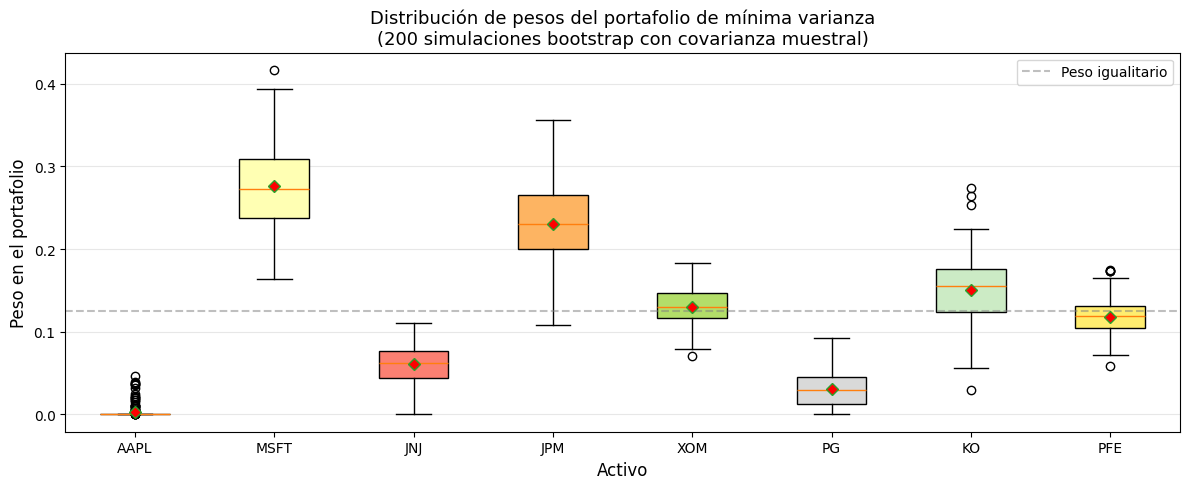

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(pesos_mc, labels=tickers, patch_artist=True, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="red", markersize=6))

colores = plt.cm.Set3(np.linspace(0, 1, n_activos))
for patch, color in zip(bp["boxes"], colores):
    patch.set_facecolor(color)

ax.set_ylabel("Peso en el portafolio", fontsize=12)
ax.set_xlabel("Activo", fontsize=12)
ax.set_title(
    f"Distribución de pesos del portafolio de mínima varianza\n"
    f"({M} simulaciones bootstrap con covarianza muestral)",
    fontsize=13,
)
ax.axhline(1 / n_activos, color="gray", linestyle="--", alpha=0.5, label="Peso igualitario")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Visualización: evolución de los pesos simulación a simulación

La siguiente gráfica de áreas apiladas muestra cómo los pesos del portafolio cambian **en cada una de las 200 simulaciones**. Si los portafolios fueran estables, veríamos franjas horizontales uniformes. La irregularidad confirma la inestabilidad.

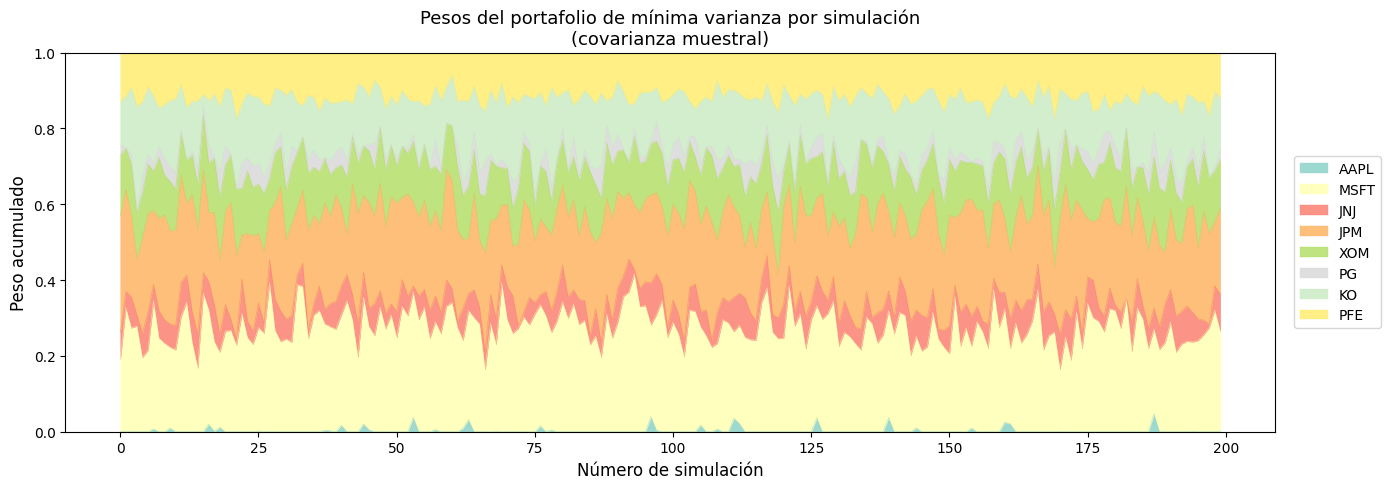

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))
df_pesos = pd.DataFrame(pesos_mc, columns=tickers)

df_pesos.plot.area(ax=ax, colormap="Set3", alpha=0.85, linewidth=0.3)
ax.set_xlabel("Número de simulación", fontsize=12)
ax.set_ylabel("Peso acumulado", fontsize=12)
ax.set_title(
    "Pesos del portafolio de mínima varianza por simulación\n(covarianza muestral)",
    fontsize=13,
)
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=10)
plt.tight_layout()
plt.show()

### Desempeño fuera de muestra (Out-of-Sample)

Ahora evaluamos si esta inestabilidad tiene consecuencias reales en el rendimiento. Usamos **splits temporales** que respetan la estructura de serie de tiempo:

1. Elegimos un punto de corte $t$ aleatorio tal que haya suficientes datos a ambos lados.
2. **In-sample** ($1, \ldots, t$): estimamos la covarianza y calculamos los pesos óptimos.
3. **Out-of-sample** ($t+1, \ldots, T$): medimos el rendimiento y la volatilidad de ese portafolio en datos **futuros** que no se usaron en la estimación.

Esto simula cómo funcionaría la estrategia en la práctica: siempre se entrena con el pasado y se evalúa hacia adelante.

In [50]:
# ─── Desempeño out-of-sample con splits temporales ───
T_total = len(datos_np)
T_min_train = T_total // 4          # mínimo 25% para entrenar
T_min_test = T_total // 4           # mínimo 25% para evaluar
M_oos = 100                          # número de splits

resultados_oos = {"muestra_vol": [], "muestra_ret": [], "eq_vol": [], "eq_ret": []}
w_eq = np.ones(n_activos) / n_activos

for i in range(M_oos):
    # Punto de corte aleatorio que respeta el orden temporal
    t_corte = np.random.randint(T_min_train, T_total - T_min_test)
    train = datos_np[:t_corte]       # pasado → entrenar
    test = datos_np[t_corte:]        # futuro → evaluar

    # In-sample: estimar covarianza y optimizar
    cov_train = np.cov(train, rowvar=False)
    w_opt = portafolio_min_varianza(cov_train)

    # Out-of-sample: rendimiento y volatilidad del portafolio
    ret_oos = test @ w_opt
    resultados_oos["muestra_ret"].append(ret_oos.mean() * 252)
    resultados_oos["muestra_vol"].append(ret_oos.std() * np.sqrt(252))

    # Benchmark: portafolio igualitario
    ret_eq = test @ w_eq
    resultados_oos["eq_ret"].append(ret_eq.mean() * 252)
    resultados_oos["eq_vol"].append(ret_eq.std() * np.sqrt(252))

df_oos = pd.DataFrame(resultados_oos)
print("Desempeño Out-of-Sample (anualizado, splits temporales):\n")
print(f"{'Métrica':<25} {'Mín. Varianza':>15} {'Igualitario (1/N)':>18}")
print("-" * 60)
print(f"{'Retorno promedio':<25} {df_oos['muestra_ret'].mean():>14.2%} {df_oos['eq_ret'].mean():>17.2%}")
print(f"{'Volatilidad promedio':<25} {df_oos['muestra_vol'].mean():>14.2%} {df_oos['eq_vol'].mean():>17.2%}")
print(f"{'Desv. est. del retorno':<25} {df_oos['muestra_ret'].std():>14.2%} {df_oos['eq_ret'].std():>17.2%}")
print(f"{'Desv. est. de la volatil.':<25} {df_oos['muestra_vol'].std():>14.2%} {df_oos['eq_vol'].std():>17.2%}")

Desempeño Out-of-Sample (anualizado, splits temporales):

Métrica                     Mín. Varianza  Igualitario (1/N)
------------------------------------------------------------
Retorno promedio                  13.87%            11.84%
Volatilidad promedio              11.76%            11.74%
Desv. est. del retorno             1.99%             1.40%
Desv. est. de la volatil.          0.21%             0.57%


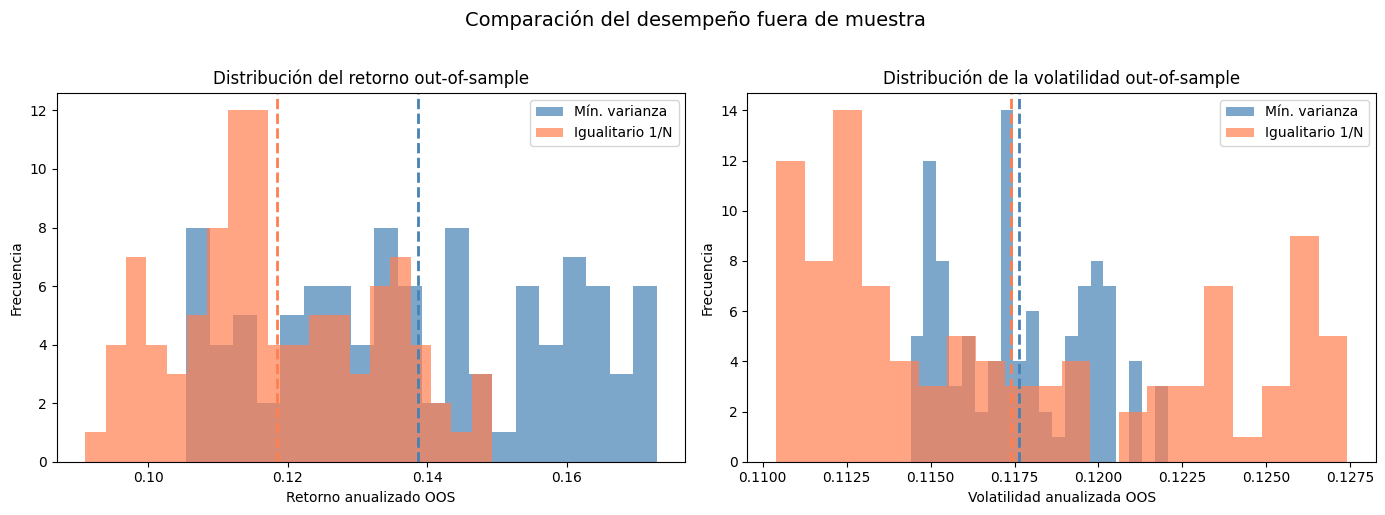

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retorno OOS
axes[0].hist(df_oos["muestra_ret"], bins=20, alpha=0.7, color="steelblue", label="Mín. varianza")
axes[0].hist(df_oos["eq_ret"], bins=20, alpha=0.7, color="coral", label="Igualitario 1/N")
axes[0].axvline(df_oos["muestra_ret"].mean(), color="steelblue", linestyle="--", lw=2)
axes[0].axvline(df_oos["eq_ret"].mean(), color="coral", linestyle="--", lw=2)
axes[0].set_xlabel("Retorno anualizado OOS")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución del retorno out-of-sample")
axes[0].legend()

# Volatilidad OOS
axes[1].hist(df_oos["muestra_vol"], bins=20, alpha=0.7, color="steelblue", label="Mín. varianza")
axes[1].hist(df_oos["eq_vol"], bins=20, alpha=0.7, color="coral", label="Igualitario 1/N")
axes[1].axvline(df_oos["muestra_vol"].mean(), color="steelblue", linestyle="--", lw=2)
axes[1].axvline(df_oos["eq_vol"].mean(), color="coral", linestyle="--", lw=2)
axes[1].set_xlabel("Volatilidad anualizada OOS")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de la volatilidad out-of-sample")
axes[1].legend()

plt.suptitle("Comparación del desempeño fuera de muestra", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Conclusión de la Parte 1

Los resultados muestran que:

- Los **pesos del portafolio de mínima varianza varían significativamente** entre simulaciones, a pesar de usar datos del mismo proceso generador.
- La **volatilidad out-of-sample** del portafolio optimizado no siempre es menor que la del portafolio igualitario $1/N$.
- El portafolio igualitario, que no requiere estimar $\Sigma$, tiene **menor dispersión** en su desempeño.

> **Esto motiva la necesidad de un mejor estimador de la covarianza.** El shrinkage de Ledoit-Wolf es una solución elegante a este problema.

---

## Parte 2: El Estimador de Ledoit-Wolf

### Intuición

El estimador de Ledoit-Wolf combina la **matriz de covarianza muestral** $\hat{\Sigma}$ con un **target estructurado** $F$ (típicamente una matriz diagonal o proporcional a la identidad):

$$\hat{\Sigma}_{LW} = \alpha \cdot F + (1 - \alpha) \cdot \hat{\Sigma}$$

donde $\alpha \in [0, 1]$ es la **intensidad de shrinkage**, determinada de forma óptima por la fórmula analítica de Ledoit y Wolf (2004).

### ¿Qué hace $\alpha$?

| Valor de $\alpha$ | Interpretación |
|:---:|:---|
| $\alpha = 0$ | Se usa la covarianza muestral pura (sin shrinkage) |
| $\alpha = 1$ | Se usa solo el target estructurado (máximo shrinkage) |
| $0 < \alpha < 1$ | **Compromiso óptimo** entre sesgo y varianza |

### ¿Por qué funciona?

- La covarianza muestral tiene **varianza alta** (muchos parámetros a estimar) pero **sesgo bajo**.
- El target tiene **varianza baja** (pocos parámetros) pero **sesgo alto**.
- El shrinkage encuentra el balance que **minimiza el error cuadrático medio** de la estimación.

In [52]:
# ─── Estimador de Ledoit-Wolf vs. Covarianza Muestral ───
cov_muestral = np.cov(datos_np, rowvar=False)

lw = LedoitWolf().fit(datos_np)
cov_lw = lw.covariance_
alpha_lw = lw.shrinkage_

print(f"Intensidad de shrinkage óptima (α): {alpha_lw:.4f}")
print(f"\nDimensiones de la matriz: {cov_lw.shape}")
print(f"\n{'':─<60}")
print(f"Comparación de las matrices de covarianza (norma de Frobenius):")
print(f"  ‖Σ_muestral‖_F    = {np.linalg.norm(cov_muestral, 'fro'):.6f}")
print(f"  ‖Σ_Ledoit-Wolf‖_F = {np.linalg.norm(cov_lw, 'fro'):.6f}")

# Número de condición (medida de estabilidad numérica)
cond_muestral = np.linalg.cond(cov_muestral)
cond_lw = np.linalg.cond(cov_lw)
print(f"\nNúmero de condición (menor = más estable):")
print(f"  κ(Σ_muestral)    = {cond_muestral:.1f}")
print(f"  κ(Σ_Ledoit-Wolf) = {cond_lw:.1f}")
print(f"  Reducción: {(1 - cond_lw/cond_muestral)*100:.1f}%")

Intensidad de shrinkage óptima (α): 0.0240

Dimensiones de la matriz: (8, 8)

────────────────────────────────────────────────────────────
Comparación de las matrices de covarianza (norma de Frobenius):
  ‖Σ_muestral‖_F    = 0.000766
  ‖Σ_Ledoit-Wolf‖_F = 0.000758

Número de condición (menor = más estable):
  κ(Σ_muestral)    = 15.7
  κ(Σ_Ledoit-Wolf) = 14.0
  Reducción: 11.0%


### Visualización: comparación de las matrices de covarianza

Visualizamos ambas matrices como mapas de calor. La matriz de Ledoit-Wolf suaviza los valores extremos fuera de la diagonal, reduciendo las covarianzas ruidosas.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_35769/3484023355.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


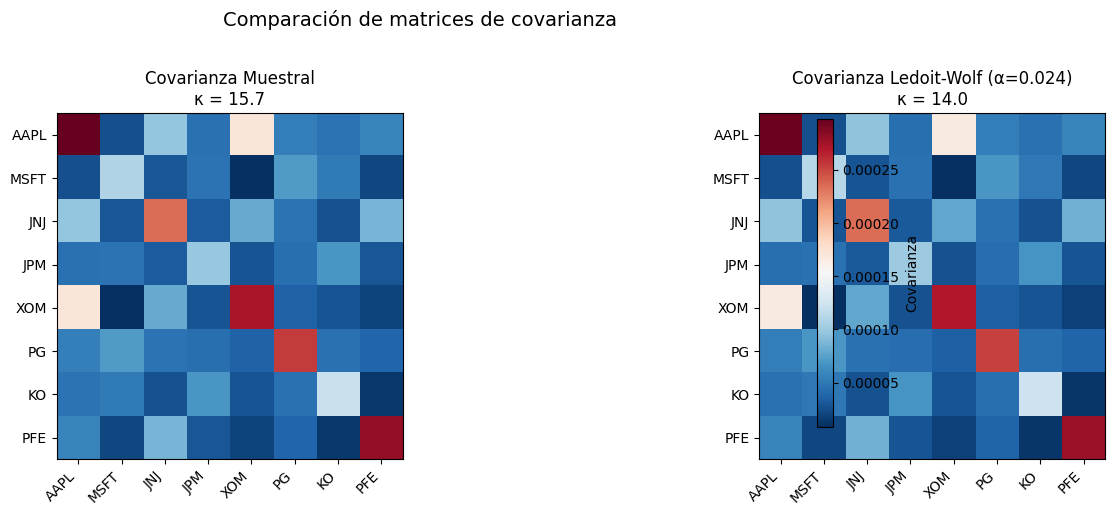

In [ ]:
# Función auxiliar para configurar ejes de heatmap
def setup_heatmap(ax, matrix, title, cmap, vmin, vmax, annotate=False, fmt=".2f"):
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(n_activos)); ax.set_xticklabels(tickers, rotation=45, ha="right")
    ax.set_yticks(range(n_activos)); ax.set_yticklabels(tickers)
    ax.set_title(title, fontsize=11, fontweight="bold")
    if annotate:
        thresh = (vmax - vmin) * 0.5 + vmin if vmin < 0 else vmax * 0.5
        for i in range(n_activos):
            for j in range(n_activos):
                color = "white" if np.abs(matrix[i,j]) > np.abs(thresh) else "black"
                ax.text(j, i, f"{matrix[i,j]:{fmt}}", ha="center", va="center", fontsize=7, color=color)
    return im

# ─── Cambio porcentual en covarianzas (más evidente que diferencia absoluta) ───
cov_anual_m, cov_anual_lw = cov_muestral * 252, cov_lw * 252
pct_cambio = (cov_anual_lw - cov_anual_m) / np.abs(cov_anual_m) * 100  # % de cambio relativo

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
vmin, vmax = min(cov_anual_m.min(), cov_anual_lw.min()), max(cov_anual_m.max(), cov_anual_lw.max())

setup_heatmap(axes[0], cov_anual_m, f"Muestral (κ={cond_muestral:.0f})", "YlOrRd", vmin, vmax)
im2 = setup_heatmap(axes[1], cov_anual_lw, f"Ledoit-Wolf (κ={cond_lw:.0f}, α={alpha_lw:.2f})", "YlOrRd", vmin, vmax)
fig.colorbar(im2, ax=axes[:2], shrink=0.7, pad=0.02, label="Cov. anualizada")

vabs = np.abs(pct_cambio).max()
im3 = setup_heatmap(axes[2], pct_cambio, "Cambio % (LW vs Muestral)", "RdBu", -vabs, vabs, annotate=True, fmt="+.1f")
fig.colorbar(im3, ax=axes[2], shrink=0.9, pad=0.02, label="% cambio")

fig.suptitle("Comparación de matrices de covarianza", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ─── Correlaciones con anotaciones ───
corr_m = np.corrcoef(datos_np, rowvar=False)
corr_lw = cov_lw / np.sqrt(np.outer(np.diag(cov_lw), np.diag(cov_lw)))
diff_corr = corr_m - corr_lw

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.5))
setup_heatmap(axes2[0], corr_m, "Correlación Muestral", "coolwarm", -1, 1, annotate=True)
im2 = setup_heatmap(axes2[1], corr_lw, "Correlación Ledoit-Wolf", "coolwarm", -1, 1, annotate=True)
fig2.colorbar(im2, ax=axes2[:2], shrink=0.9, pad=0.02, label="Correlación")

vabs_corr = max(np.abs(diff_corr).max(), 0.01)
im3 = setup_heatmap(axes2[2], diff_corr, "Diferencia (Muestral − LW)", "PuOr", -vabs_corr, vabs_corr, annotate=True, fmt="+.3f")
fig2.colorbar(im3, ax=axes2[2], shrink=0.9, pad=0.02, label="Δ Corr.")

fig2.suptitle("Comparación de matrices de correlación", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Resumen compacto
off_diag = ~np.eye(n_activos, dtype=bool)
print(f"\nDiferencias: Cov. max={np.abs(cov_anual_m - cov_anual_lw).max():.4f} | "
      f"Corr. max={np.abs(diff_corr).max():.4f}, prom={np.abs(diff_corr[off_diag]).mean():.4f}")

### Comparación de valores propios

Los valores propios de la matriz de covarianza determinan las "direcciones de riesgo". Valores propios extremos (muy grandes o muy pequeños) indican inestabilidad. El shrinkage acerca los valores propios entre sí, mejorando el condicionamiento.

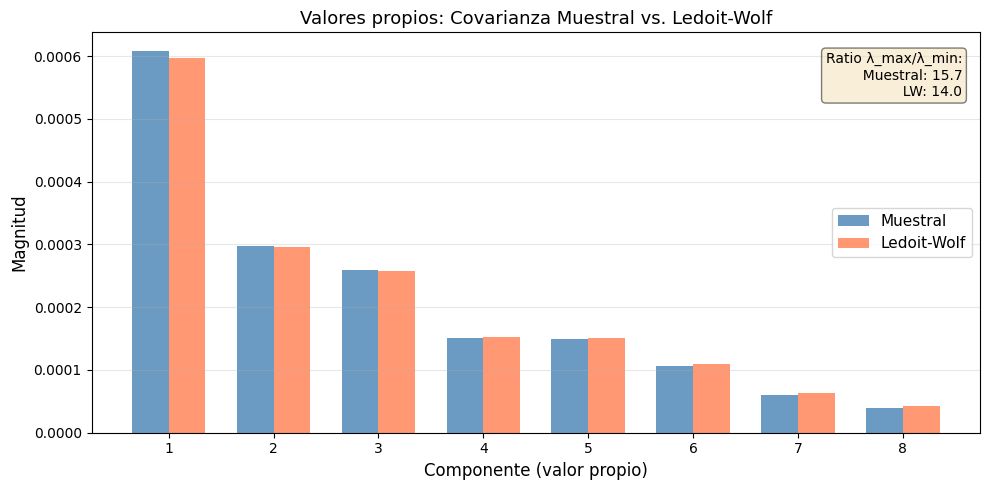

In [54]:
eigenvalues_sample = np.sort(np.linalg.eigvalsh(cov_muestral))[::-1]
eigenvalues_lw = np.sort(np.linalg.eigvalsh(cov_lw))[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, n_activos + 1)
ancho = 0.35

bars1 = ax.bar(x - ancho / 2, eigenvalues_sample, ancho, label="Muestral", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + ancho / 2, eigenvalues_lw, ancho, label="Ledoit-Wolf", color="coral", alpha=0.8)

ax.set_xlabel("Componente (valor propio)", fontsize=12)
ax.set_ylabel("Magnitud", fontsize=12)
ax.set_title("Valores propios: Covarianza Muestral vs. Ledoit-Wolf", fontsize=13)
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

# Anotar ratio
ratio = eigenvalues_sample[0] / eigenvalues_sample[-1]
ratio_lw = eigenvalues_lw[0] / eigenvalues_lw[-1]
ax.text(0.98, 0.95,
        f"Ratio λ_max/λ_min:\n  Muestral: {ratio:.1f}\n  LW: {ratio_lw:.1f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

---

## Parte 3: Comparación de Estabilidad — Monte Carlo con Ledoit-Wolf

Ahora repetimos el mismo experimento de Monte Carlo de la Parte 1, pero esta vez calculamos los pesos del portafolio de mínima varianza usando **ambos** estimadores:

1. **Covarianza muestral** (ya calculada antes)
2. **Covarianza de Ledoit-Wolf**

Si el shrinkage funciona, esperamos que los pesos con Ledoit-Wolf sean **menos dispersos** (más estables) a través de las simulaciones.

In [55]:
# ─── Monte Carlo comparando ambos estimadores ───
pesos_mc_muestral = np.zeros((M, n_activos))
pesos_mc_lw = np.zeros((M, n_activos))
alphas_lw = np.zeros(M)

for i in range(M):
    idx = np.random.choice(len(datos_np), size=T_sub, replace=True)
    muestra = datos_np[idx]

    # 1. Covarianza muestral
    cov_s = np.cov(muestra, rowvar=False)
    pesos_mc_muestral[i] = portafolio_min_varianza(cov_s)

    # 2. Covarianza Ledoit-Wolf
    lw_fit = LedoitWolf().fit(muestra)
    cov_lw_i = lw_fit.covariance_
    alphas_lw[i] = lw_fit.shrinkage_
    pesos_mc_lw[i] = portafolio_min_varianza(cov_lw_i)

# Resumen de estabilidad
print(f"Simulaciones: {M} | Sub-muestra: {T_sub} días\n")
print(f"{'Activo':<8} {'Muestral (μ ± σ)':>20} {'Ledoit-Wolf (μ ± σ)':>22} {'Reducción σ':>14}")
print("─" * 68)
for j, t in enumerate(tickers):
    std_s = pesos_mc_muestral[:, j].std()
    std_lw = pesos_mc_lw[:, j].std()
    reduccion = (1 - std_lw / std_s) * 100 if std_s > 0 else 0
    print(f"{t:<8} {pesos_mc_muestral[:, j].mean():>8.3f} ± {std_s:.3f}"
          f"    {pesos_mc_lw[:, j].mean():>8.3f} ± {std_lw:.3f}"
          f"    {reduccion:>10.1f}%")

print(f"\nIntensidad de shrinkage promedio: α = {alphas_lw.mean():.4f} ± {alphas_lw.std():.4f}")

Simulaciones: 200 | Sub-muestra: 627 días

Activo       Muestral (μ ± σ)    Ledoit-Wolf (μ ± σ)    Reducción σ
────────────────────────────────────────────────────────────────────
AAPL        0.003 ± 0.008       0.005 ± 0.010         -22.3%
MSFT        0.281 ± 0.047       0.266 ± 0.040          15.2%
JNJ         0.062 ± 0.024       0.067 ± 0.023           6.4%
JPM         0.229 ± 0.054       0.220 ± 0.044          18.7%
XOM         0.127 ± 0.022       0.126 ± 0.021           5.0%
PG          0.028 ± 0.021       0.036 ± 0.021           0.7%
KO          0.150 ± 0.037       0.160 ± 0.030          18.8%
PFE         0.118 ± 0.020       0.120 ± 0.019           5.3%

Intensidad de shrinkage promedio: α = 0.0460 ± 0.0075


### Comparación lado a lado: boxplots de pesos

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_35769/485090799.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(pesos_mc_muestral, labels=tickers, patch_artist=True,
/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_35769/485090799.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(pesos_mc_lw, labels=tickers, patch_artist=True,


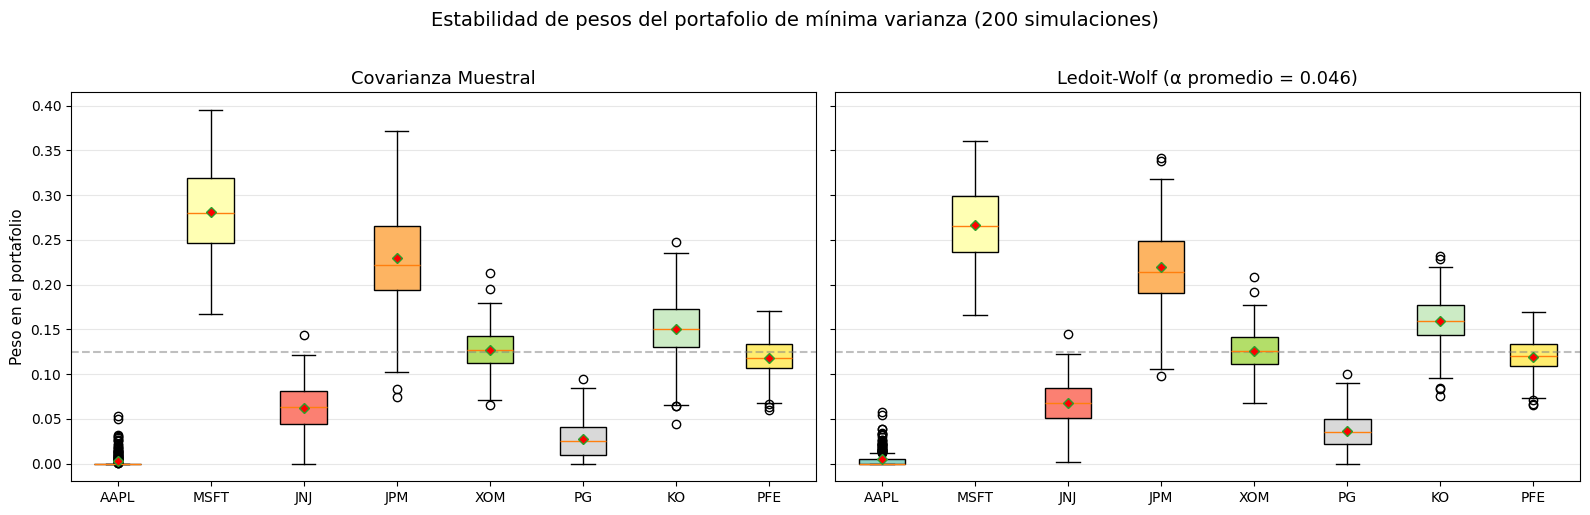

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Boxplot - Covarianza Muestral
bp1 = axes[0].boxplot(pesos_mc_muestral, labels=tickers, patch_artist=True,
                       showmeans=True, meanprops=dict(marker="D", markerfacecolor="red", markersize=5))
for patch, c in zip(bp1["boxes"], plt.cm.Set3(np.linspace(0, 1, n_activos))):
    patch.set_facecolor(c)
axes[0].set_title("Covarianza Muestral", fontsize=13)
axes[0].set_ylabel("Peso en el portafolio", fontsize=11)
axes[0].axhline(1 / n_activos, color="gray", linestyle="--", alpha=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Boxplot - Ledoit-Wolf
bp2 = axes[1].boxplot(pesos_mc_lw, labels=tickers, patch_artist=True,
                       showmeans=True, meanprops=dict(marker="D", markerfacecolor="red", markersize=5))
for patch, c in zip(bp2["boxes"], plt.cm.Set3(np.linspace(0, 1, n_activos))):
    patch.set_facecolor(c)
axes[1].set_title(f"Ledoit-Wolf (α promedio = {alphas_lw.mean():.3f})", fontsize=13)
axes[1].axhline(1 / n_activos, color="gray", linestyle="--", alpha=0.5)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Estabilidad de pesos del portafolio de mínima varianza ({M} simulaciones)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

### Visualización directa de la diferencia

Los boxplots lado a lado comparten la misma escala, lo que dificulta percibir las diferencias. Para evidenciar el efecto del shrinkage usamos dos gráficos adicionales:

1. **Boxplots superpuestos**: ambos métodos en el mismo eje por activo, para comparación directa.
2. **Reducción de la desviación estándar**: un gráfico de barras que muestra cuánto se reduce la variabilidad de cada peso.

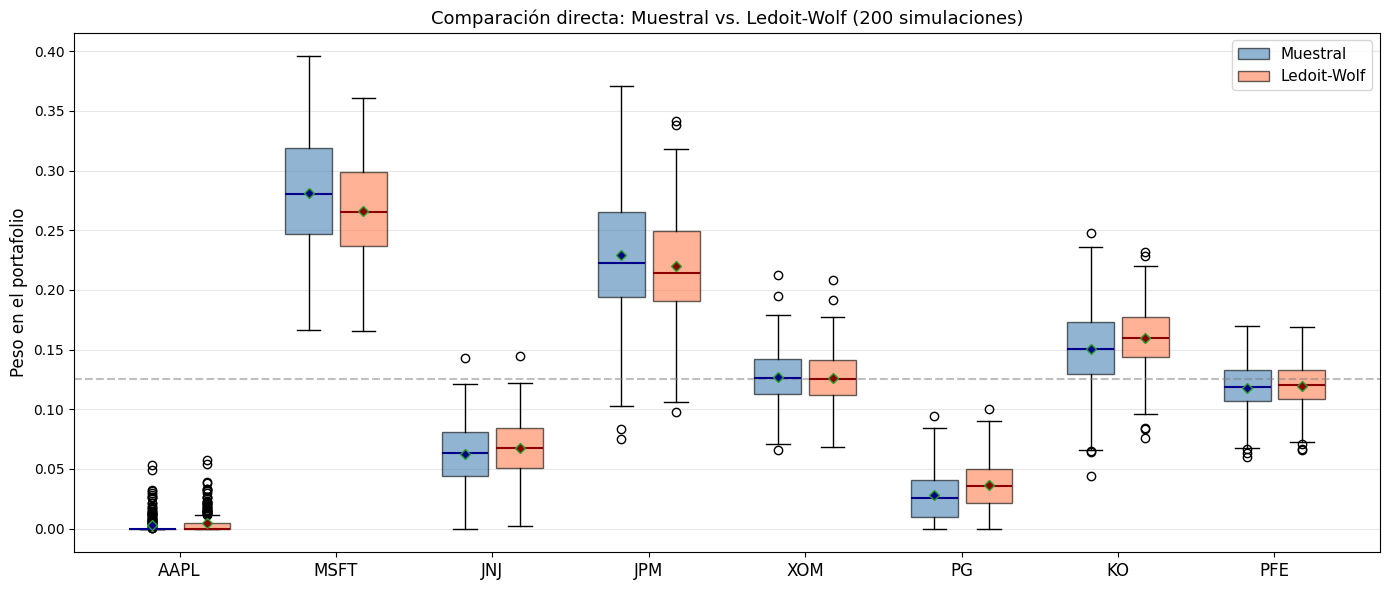

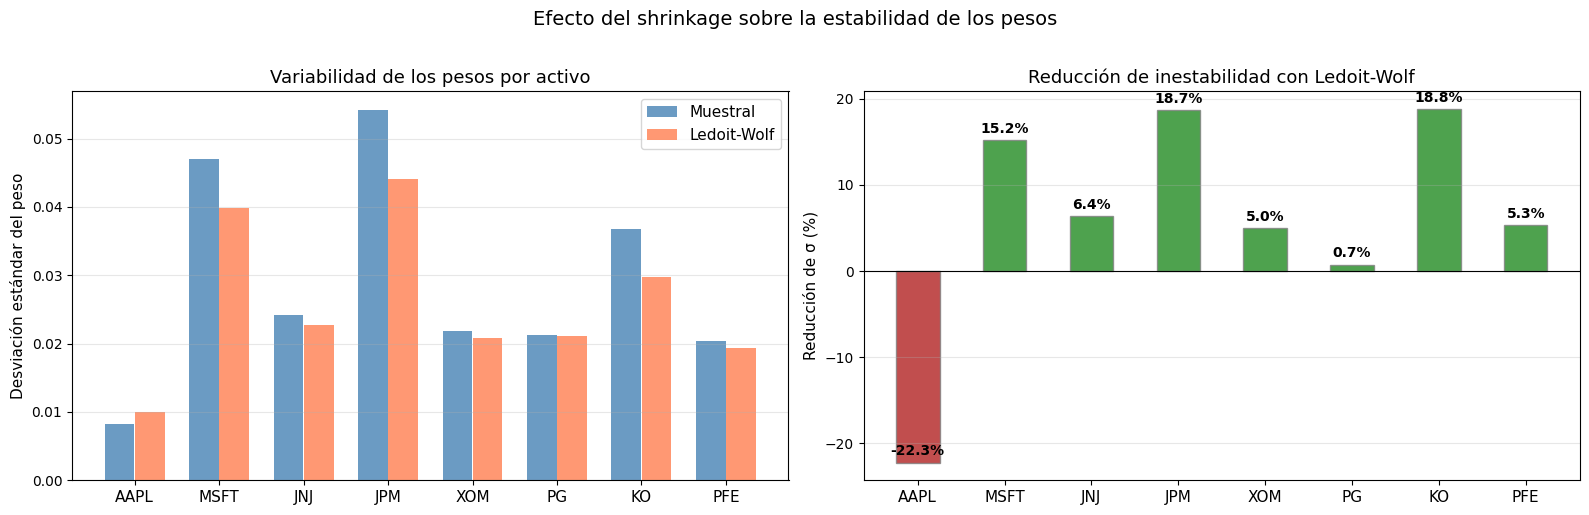

In [57]:
# ─── 1. Boxplots superpuestos: comparación directa por activo ───
fig, ax = plt.subplots(figsize=(14, 6))

positions = np.arange(n_activos)
ancho_box = 0.35

bp1 = ax.boxplot(pesos_mc_muestral, positions=positions - ancho_box/2,
                 widths=0.3, patch_artist=True, showmeans=True,
                 meanprops=dict(marker="D", markerfacecolor="darkblue", markersize=5),
                 medianprops=dict(color="darkblue", lw=1.5))
bp2 = ax.boxplot(pesos_mc_lw, positions=positions + ancho_box/2,
                 widths=0.3, patch_artist=True, showmeans=True,
                 meanprops=dict(marker="D", markerfacecolor="darkred", markersize=5),
                 medianprops=dict(color="darkred", lw=1.5))

for patch in bp1["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
for patch in bp2["boxes"]:
    patch.set_facecolor("coral")
    patch.set_alpha(0.6)

ax.set_xticks(positions)
ax.set_xticklabels(tickers, fontsize=12)
ax.set_ylabel("Peso en el portafolio", fontsize=12)
ax.set_title(f"Comparación directa: Muestral vs. Ledoit-Wolf ({M} simulaciones)", fontsize=13)
ax.axhline(1 / n_activos, color="gray", linestyle="--", alpha=0.5, label="Peso igualitario (1/N)")
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Muestral", "Ledoit-Wolf"],
          fontsize=11, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ─── 2. Reducción de desviación estándar por activo ───
std_muestral = pesos_mc_muestral.std(axis=0)
std_lw = pesos_mc_lw.std(axis=0)
reduccion_pct = (1 - std_lw / std_muestral) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: barras de desviación estándar
x = np.arange(n_activos)
bars1 = axes[0].bar(x - 0.18, std_muestral, 0.35, label="Muestral", color="steelblue", alpha=0.8)
bars2 = axes[0].bar(x + 0.18, std_lw, 0.35, label="Ledoit-Wolf", color="coral", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(tickers, fontsize=11)
axes[0].set_ylabel("Desviación estándar del peso", fontsize=11)
axes[0].set_title("Variabilidad de los pesos por activo", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# Panel derecho: porcentaje de reducción
colores_red = ["forestgreen" if r > 0 else "firebrick" for r in reduccion_pct]
bars3 = axes[1].bar(x, reduccion_pct, 0.5, color=colores_red, alpha=0.8, edgecolor="gray")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tickers, fontsize=11)
axes[1].set_ylabel("Reducción de σ (%)", fontsize=11)
axes[1].set_title("Reducción de inestabilidad con Ledoit-Wolf", fontsize=13)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].grid(axis="y", alpha=0.3)

# Anotar valores sobre cada barra
for bar, val in zip(bars3, reduccion_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Efecto del shrinkage sobre la estabilidad de los pesos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Métrica de estabilidad: norma de la diferencia de pesos

Para cuantificar la estabilidad, calculamos la **desviación media absoluta** de los pesos entre simulaciones consecutivas. Un estimador estable produce diferencias pequeñas.

In [58]:
# Turnover (cambio medio de pesos entre simulaciones consecutivas)
turnover_muestral = np.mean(np.sum(np.abs(np.diff(pesos_mc_muestral, axis=0)), axis=1))
turnover_lw = np.mean(np.sum(np.abs(np.diff(pesos_mc_lw, axis=0)), axis=1))

# Desviación estándar total de los pesos
std_total_muestral = np.sqrt(np.sum(pesos_mc_muestral.std(axis=0) ** 2))
std_total_lw = np.sqrt(np.sum(pesos_mc_lw.std(axis=0) ** 2))

print("Métricas de estabilidad de los pesos:")
print(f"{'':─<55}")
print(f"{'Métrica':<35} {'Muestral':>10} {'Ledoit-Wolf':>10}")
print(f"{'':─<55}")
print(f"{'Turnover promedio':<35} {turnover_muestral:>10.4f} {turnover_lw:>10.4f}")
print(f"{'Desviac. estándar total':<35} {std_total_muestral:>10.4f} {std_total_lw:>10.4f}")
print(f"{'Reducción de inestabilidad':<35} {'':>10} {(1 - std_total_lw/std_total_muestral)*100:>9.1f}%")

Métricas de estabilidad de los pesos:
───────────────────────────────────────────────────────
Métrica                               Muestral Ledoit-Wolf
───────────────────────────────────────────────────────
Turnover promedio                       0.2663     0.2355
Desviac. estándar total                 0.0921     0.0793
Reducción de inestabilidad                          14.0%


### Desempeño out-of-sample: Muestral vs. Ledoit-Wolf vs. 1/N

Finalmente, comparamos el desempeño **fuera de muestra** de los tres portafolios.

In [59]:
# ─── Desempeño out-of-sample: 3 estrategias (splits temporales) ───
resultados = {"ret_muestra": [], "vol_muestra": [],
              "ret_lw": [], "vol_lw": [],
              "ret_eq": [], "vol_eq": []}

for i in range(M_oos):
    # Punto de corte temporal aleatorio
    t_corte = np.random.randint(T_min_train, T_total - T_min_test)
    train = datos_np[:t_corte]       # pasado
    test = datos_np[t_corte:]        # futuro

    # Muestral
    cov_s = np.cov(train, rowvar=False)
    w_s = portafolio_min_varianza(cov_s)
    r_s = test @ w_s
    resultados["ret_muestra"].append(r_s.mean() * 252)
    resultados["vol_muestra"].append(r_s.std() * np.sqrt(252))

    # Ledoit-Wolf
    cov_lw_i = LedoitWolf().fit(train).covariance_
    w_lw = portafolio_min_varianza(cov_lw_i)
    r_lw = test @ w_lw
    resultados["ret_lw"].append(r_lw.mean() * 252)
    resultados["vol_lw"].append(r_lw.std() * np.sqrt(252))

    # Igualitario
    r_eq = test @ w_eq
    resultados["ret_eq"].append(r_eq.mean() * 252)
    resultados["vol_eq"].append(r_eq.std() * np.sqrt(252))

df_comp = pd.DataFrame(resultados)

# Sharpe ratio OOS aproximado
sharpe_s = (df_comp["ret_muestra"] - rf_anual) / df_comp["vol_muestra"]
sharpe_lw = (df_comp["ret_lw"] - rf_anual) / df_comp["vol_lw"]
sharpe_eq = (df_comp["ret_eq"] - rf_anual) / df_comp["vol_eq"]

print("Comparación Out-of-Sample (anualizado, splits temporales):\n")
print(f"{'Métrica':<30} {'Muestral':>12} {'Ledoit-Wolf':>12} {'1/N':>12}")
print("─" * 68)
print(f"{'Retorno medio':<30} {df_comp['ret_muestra'].mean():>11.2%} {df_comp['ret_lw'].mean():>11.2%} {df_comp['ret_eq'].mean():>11.2%}")
print(f"{'Volatilidad media':<30} {df_comp['vol_muestra'].mean():>11.2%} {df_comp['vol_lw'].mean():>11.2%} {df_comp['vol_eq'].mean():>11.2%}")
print(f"{'Sharpe ratio medio':<30} {sharpe_s.mean():>11.3f} {sharpe_lw.mean():>11.3f} {sharpe_eq.mean():>11.3f}")
print(f"{'Desv. est. del Sharpe':<30} {sharpe_s.std():>11.3f} {sharpe_lw.std():>11.3f} {sharpe_eq.std():>11.3f}")

Comparación Out-of-Sample (anualizado, splits temporales):

Métrica                            Muestral  Ledoit-Wolf          1/N
────────────────────────────────────────────────────────────────────
Retorno medio                       13.99%      13.68%      12.03%
Volatilidad media                   11.81%      11.70%      11.71%
Sharpe ratio medio                   0.763       0.743       0.603
Desv. est. del Sharpe                0.176       0.176       0.118


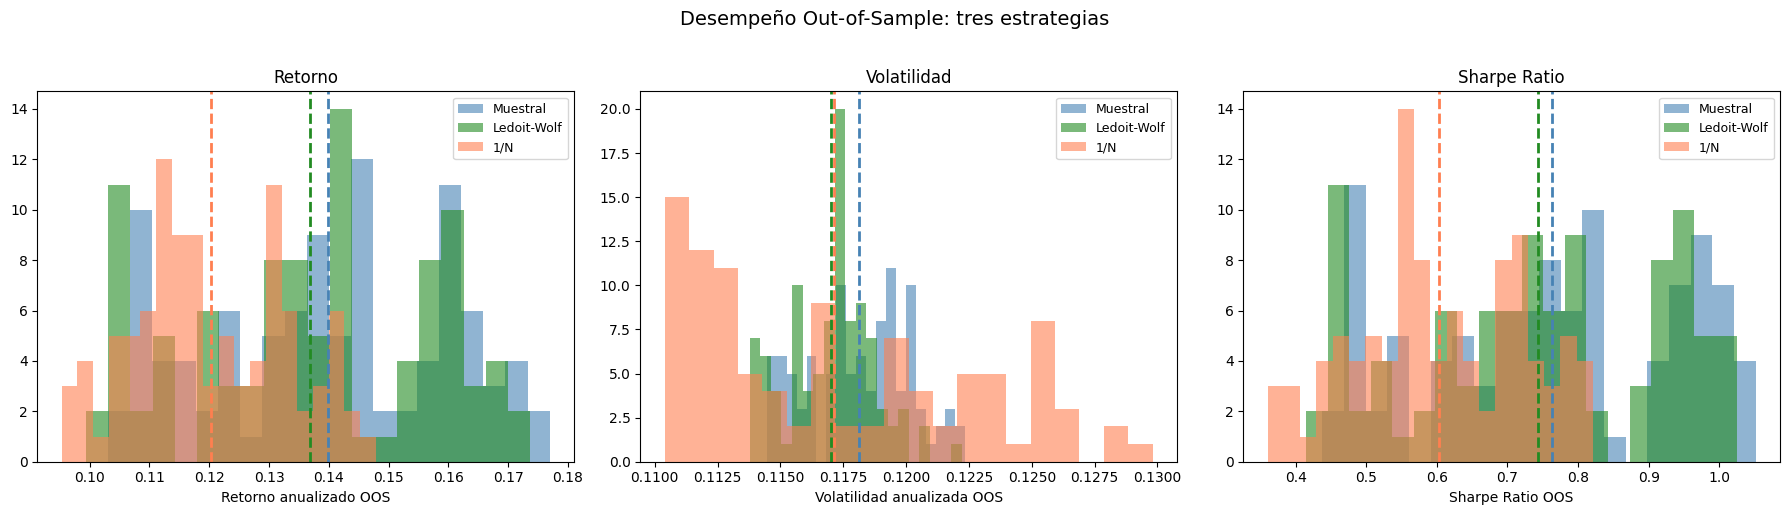

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Retorno OOS
for datos_hist, label, color in [
    (df_comp["ret_muestra"], "Muestral", "steelblue"),
    (df_comp["ret_lw"], "Ledoit-Wolf", "forestgreen"),
    (df_comp["ret_eq"], "1/N", "coral"),
]:
    axes[0].hist(datos_hist, bins=20, alpha=0.6, color=color, label=label)
    axes[0].axvline(datos_hist.mean(), color=color, linestyle="--", lw=2)
axes[0].set_xlabel("Retorno anualizado OOS")
axes[0].set_title("Retorno")
axes[0].legend(fontsize=9)

# Volatilidad OOS
for datos_hist, label, color in [
    (df_comp["vol_muestra"], "Muestral", "steelblue"),
    (df_comp["vol_lw"], "Ledoit-Wolf", "forestgreen"),
    (df_comp["vol_eq"], "1/N", "coral"),
]:
    axes[1].hist(datos_hist, bins=20, alpha=0.6, color=color, label=label)
    axes[1].axvline(datos_hist.mean(), color=color, linestyle="--", lw=2)
axes[1].set_xlabel("Volatilidad anualizada OOS")
axes[1].set_title("Volatilidad")
axes[1].legend(fontsize=9)

# Sharpe OOS
for datos_hist, label, color in [
    (sharpe_s, "Muestral", "steelblue"),
    (sharpe_lw, "Ledoit-Wolf", "forestgreen"),
    (sharpe_eq, "1/N", "coral"),
]:
    axes[2].hist(datos_hist, bins=20, alpha=0.6, color=color, label=label)
    axes[2].axvline(datos_hist.mean(), color=color, linestyle="--", lw=2)
axes[2].set_xlabel("Sharpe Ratio OOS")
axes[2].set_title("Sharpe Ratio")
axes[2].legend(fontsize=9)

plt.suptitle("Desempeño Out-of-Sample: tres estrategias", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Gráfico de áreas: estabilidad visual de Ledoit-Wolf

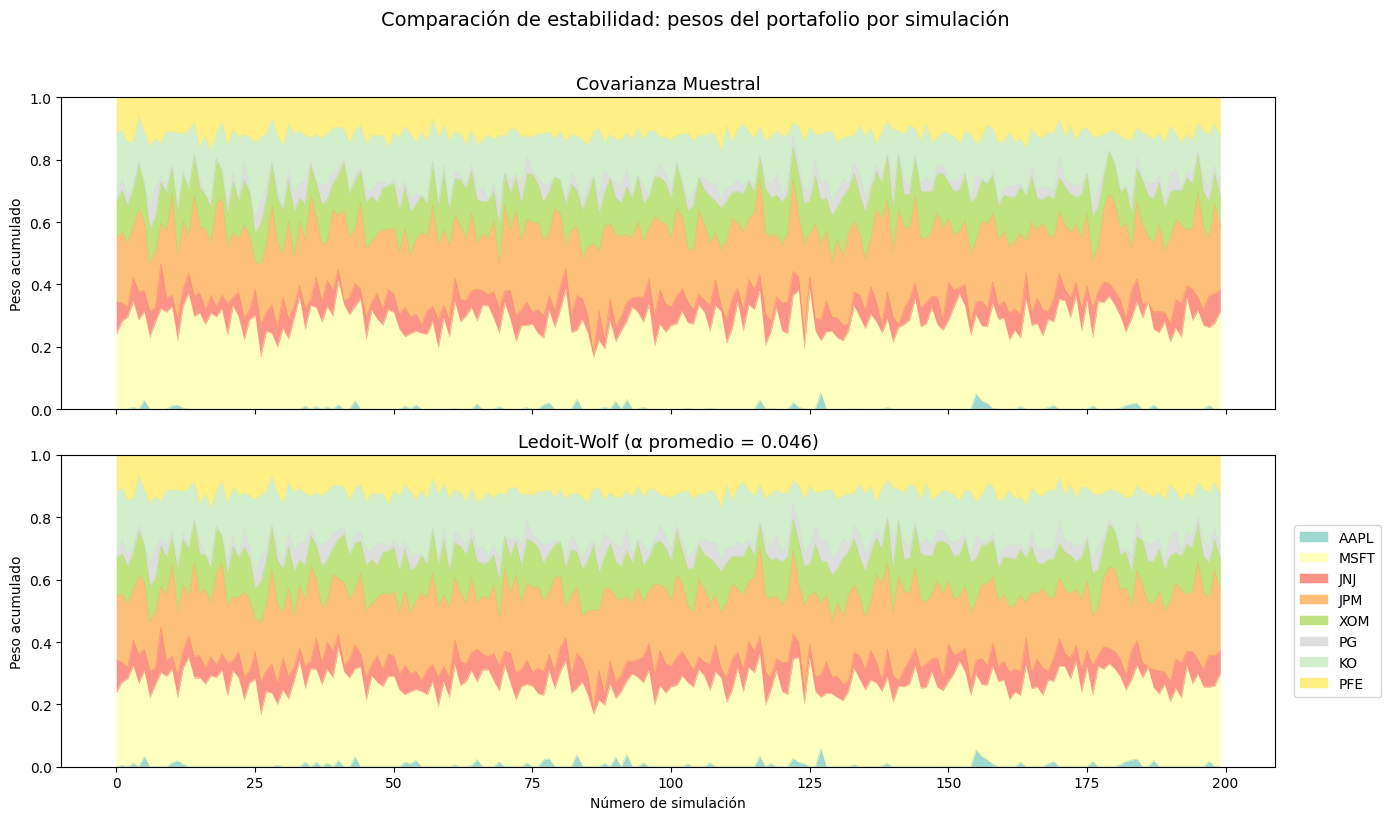

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

df_pesos_s = pd.DataFrame(pesos_mc_muestral, columns=tickers)
df_pesos_lw = pd.DataFrame(pesos_mc_lw, columns=tickers)

df_pesos_s.plot.area(ax=axes[0], colormap="Set3", alpha=0.85, linewidth=0.3, legend=False)
axes[0].set_title("Covarianza Muestral", fontsize=13)
axes[0].set_ylabel("Peso acumulado")
axes[0].set_ylim(0, 1)

df_pesos_lw.plot.area(ax=axes[1], colormap="Set3", alpha=0.85, linewidth=0.3)
axes[1].set_title(f"Ledoit-Wolf (α promedio = {alphas_lw.mean():.3f})", fontsize=13)
axes[1].set_xlabel("Número de simulación")
axes[1].set_ylabel("Peso acumulado")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=10)

plt.suptitle(
    "Comparación de estabilidad: pesos del portafolio por simulación",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

---

## Conclusiones

### ¿Qué aprendimos?

1. **La covarianza muestral produce portafolios inestables**: con simulaciones de Monte Carlo confirmamos que los pesos del portafolio de mínima varianza cambian drásticamente entre sub-muestras. Esto limita su utilidad práctica.

2. **El estimador de Ledoit-Wolf reduce significativamente la inestabilidad**: al aplicar un shrinkage óptimo hacia un target estructurado, los pesos se vuelven más estables y predecibles.

3. **El número de condición se reduce**: la matriz de Ledoit-Wolf está mejor condicionada, lo que hace que la inversión $\Sigma^{-1}$ sea numéricamente más estable.

4. **Mejor desempeño out-of-sample**: el portafolio con Ledoit-Wolf tiende a ofrecer un mejor balance entre retorno y volatilidad fuera de muestra respecto a la covarianza muestral pura.

### Cuándo usar shrinkage

| Situación | Recomendación |
|:---|:---|
| $T/N > 10$ y datos estables | La covarianza muestral puede ser aceptable |
| $T/N < 5$ o muchos activos | **Ledoit-Wolf es altamente recomendable** |
| Portafolios rebalanceados frecuentemente | Shrinkage reduce el turnover y los costos de transacción |
| Combinación con Black-Litterman | Se puede usar $\Sigma_{LW}$ en lugar de $\hat{\Sigma}$ en el modelo BL |

### Referencias

- Ledoit, O. & Wolf, M. (2004). *A well-conditioned estimator for large-dimensional covariance matrices*. Journal of Multivariate Analysis, 88(2), 365-411.
- Ledoit, O. & Wolf, M. (2003). *Improved estimation of the covariance matrix of stock returns with an application to portfolio selection*. Journal of Empirical Finance, 10(5), 603-621.
- DeMiguel, V., Garlappi, L. & Uppal, R. (2009). *Optimal versus naive diversification: How inefficient is the 1/N portfolio strategy?* Review of Financial Studies, 22(5), 1915-1953.